In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

In [6]:
from google.colab import files
uploaded = files.upload()
# bank-full.csv upload చేయి

df = pd.read_csv('bank-full.csv', sep=';')
print("Shape:", df.shape)
df.head()

Saving bank-full.csv to bank-full.csv
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
df['converted'] = df['y'].map({'yes': 1, 'no': 0})

total_leads = len(df)
contacted = df[df['contact'] != 'unknown'].shape[0]
interested = df[df['poutcome'].isin(['success','other'])].shape[0]
converted = df['converted'].sum()

funnel = {
    'Total Leads': total_leads,
    'Contacted': contacted,
    'Showed Interest': interested,
    'Converted': converted
}

for stage, count in funnel.items():
    pct = count/total_leads*100
    print(f"{stage:20s}: {count:6d} ({pct:.1f}%)")

Total Leads         :  45211 (100.0%)
Contacted           :  32191 (71.2%)
Showed Interest     :   3351 (7.4%)
Converted           :   5289 (11.7%)


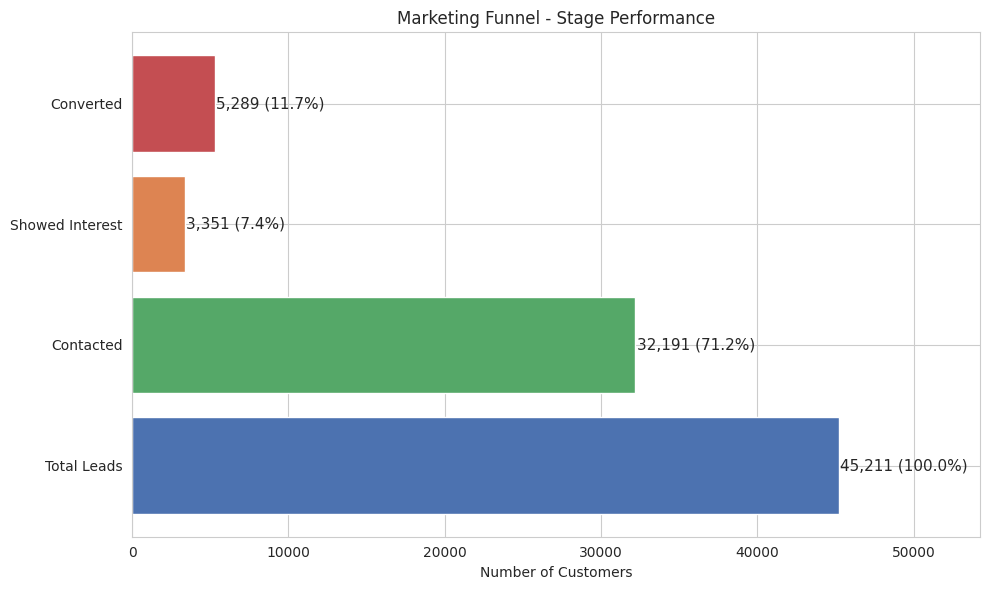

In [8]:
stages = list(funnel.keys())
values = list(funnel.values())
colors = ['#4C72B0','#55A868','#DD8452','#C44E52']

plt.figure(figsize=(10, 6))
bars = plt.barh(stages, values, color=colors)
for bar, val in zip(bars, values):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({val/total_leads*100:.1f}%)', va='center', fontsize=11)
plt.title('Marketing Funnel - Stage Performance')
plt.xlabel('Number of Customers')
plt.xlim(0, max(values) * 1.2)
plt.tight_layout()
plt.show()

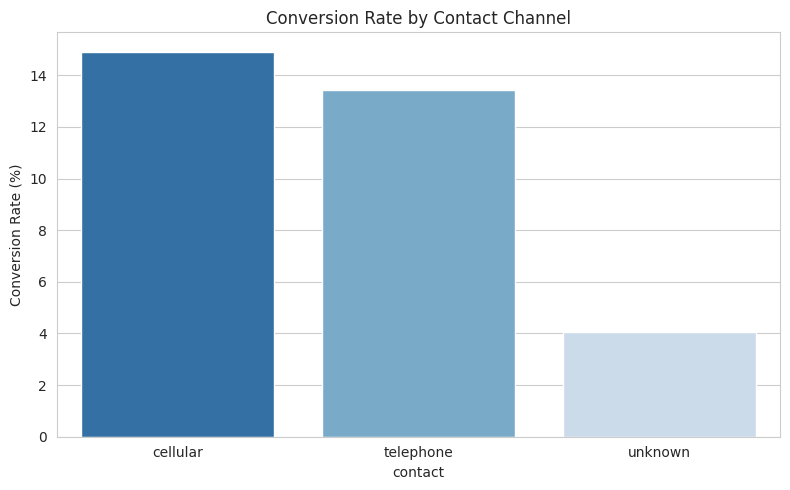

In [9]:
channel_conv = df.groupby('contact')['converted'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=channel_conv.index, y=channel_conv.values, palette='Blues_r')
plt.title('Conversion Rate by Contact Channel')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

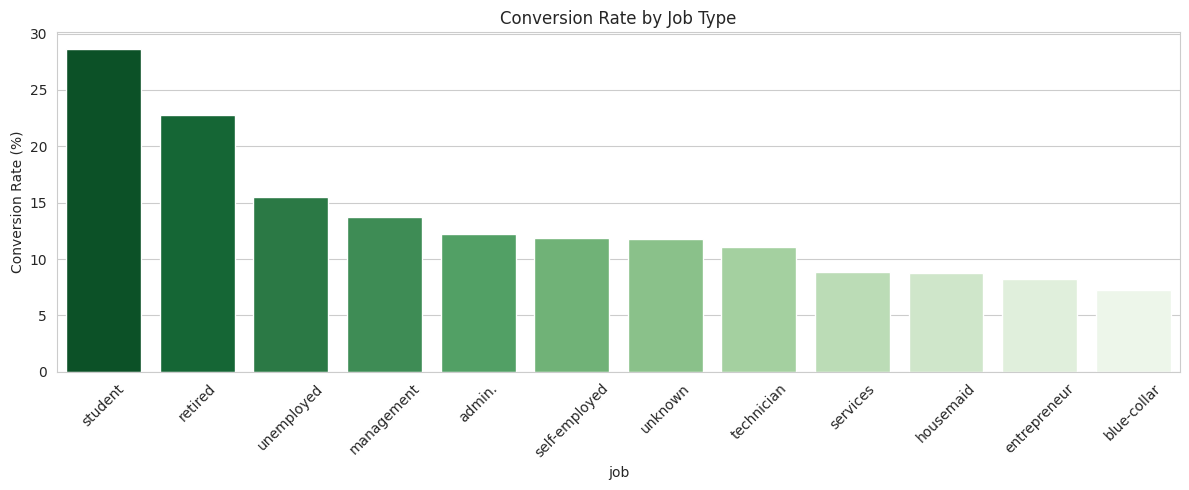

In [10]:
job_conv = df.groupby('job')['converted'].mean() * 100
job_conv = job_conv.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=job_conv.index, y=job_conv.values, palette='Greens_r')
plt.title('Conversion Rate by Job Type')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

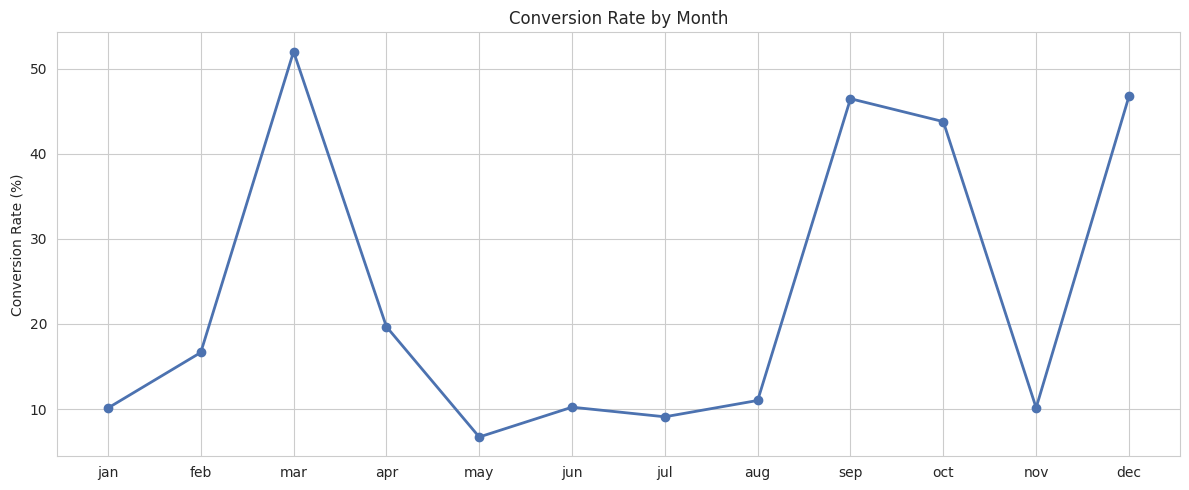

In [11]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
month_conv = df.groupby('month')['converted'].mean() * 100
month_conv = month_conv.reindex(month_order).dropna()

plt.figure(figsize=(12, 5))
plt.plot(month_conv.index, month_conv.values, marker='o', color='#4C72B0', linewidth=2)
plt.title('Conversion Rate by Month')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

In [12]:
conv_rate = df['converted'].mean() * 100
best_channel = channel_conv.idxmax()
best_month = month_conv.idxmax()
best_job = job_conv.idxmax()
drop_off = (total_leads - converted) / total_leads * 100

print(f"Overall Conversion Rate : {conv_rate:.1f}%")
print(f"Total Drop-off Rate     : {drop_off:.1f}%")
print(f"Best Channel            : {best_channel}")
print(f"Best Month              : {best_month}")
print(f"Best Job Segment        : {best_job}")

Overall Conversion Rate : 11.7%
Total Drop-off Rate     : 88.3%
Best Channel            : cellular
Best Month              : mar
Best Job Segment        : student
